In [ ]:
# -*- coding: utf-8 -*-
"""
╔══════════════════════════════════════════════════════════════╗
║         AgroIA Eventualidades v2.0                          ║
║         Evaluación satelital de daño agrícola               ║
║         con ponderación fenológica                          ║
║                                                              ║
║  Método: ΔNDVI relativo × peso fenológico × factor 0.92     ║
║  Fuente: Sentinel-2 L2A (Copernicus) + baseline 3 años      ║
╚══════════════════════════════════════════════════════════════╝
"""
!pip install geemap geopandas -q

import ee
import geemap
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print('✅ Librerias instaladas y cargadas')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.8 MB/s eta 0:00:00
✅ Librerias instaladas y cargadas


In [ ]:
# ============================================================
# CELDA 2 — Autenticación GEE
# ============================================================
try:
    ee.Initialize(project='applied-oxygen-459415-e2')
    print('✅ GEE inicializado correctamente')
except:
    ee.Authenticate()
    ee.Initialize(project='applied-oxygen-459415-e2')
    print('✅ Autenticacion y inicializacion completada')

✅ Autenticacion y inicializacion completada


In [ ]:
# ============================================================
# CELDA 3 — TABLA FENOLOGICA (diferenciador metodologico)
# ============================================================
# Fuente: criterio agronomico validado empiricamente.
# Un mismo delta-NDVI vale distinto segun el momento del ciclo.
# Peso 1.0 = etapa critica; 0.2 = etapa de poco impacto economico.

TABLA_FENOLOGICA = {
    # (cultivo, mes_evento): (descripcion_etapa, peso)
    ('maiz',    1): ('Floracion / llenado de grano (R1-R4)',   1.0),
    ('maiz',    2): ('Llenado / madurez fisiologica (R4-R6)',  0.9),
    ('maiz',    3): ('Madurez / cosecha (R6+)',                0.2),
    ('maiz',    4): ('Post-cosecha / barbecho',                0.1),
    ('maiz',   11): ('Implantacion / V1-V3',                   0.3),
    ('maiz',   12): ('Vegetativo activo (V4-V10)',              0.6),
    ('soja',    1): ('Floracion / llenado (R1-R5)',             1.0),
    ('soja',    2): ('Llenado de grano / madurez (R5-R7)',      0.8),
    ('soja',    3): ('Madurez / cosecha (R8)',                  0.2),
    ('soja',   11): ('Implantacion / VC-V2',                   0.3),
    ('soja',   12): ('Vegetativo (V3-V6)',                     0.6),
    ('trigo',   7): ('Macollaje temprano (Z21-Z29)',            0.2),
    ('trigo',   8): ('Encañazon (Z30-Z39)',                    0.5),
    ('trigo',   9): ('Espigaon / antesis (Z55-Z69)',           1.0),
    ('trigo',  10): ('Antesis / llenado de grano (critico)',   1.0),
    ('trigo',  11): ('Madurez / cosecha',                      0.3),
    ('girasol', 1): ('Floracion / llenado (R5-R7)',            1.0),
    ('girasol', 2): ('Madurez / cosecha (R8-R9)',              0.3),
    ('girasol',12): ('Vegetativo (V4-V10)',                    0.5),
}

FACTOR_CONSERVADOR = 0.92  # Prudencia ante aseguradora

def get_peso_fenologico(cultivo, mes):
    key = (cultivo.lower().strip(), mes)
    if key in TABLA_FENOLOGICA:
        return TABLA_FENOLOGICA[key]
    print(f'  Combinacion {cultivo}/{mes} no en tabla. Usando peso neutro 0.5')
    return (f'Etapa no especificada ({cultivo}, mes {mes})', 0.5)

print('✅ Tabla fenologica cargada')
print(f'   Cultivos: maiz, soja, trigo, girasol')
print(f'   Factor conservador: {FACTOR_CONSERVADOR}')

✅ Tabla fenologica cargada
   Cultivos: maiz, soja, trigo, girasol
   Factor conservador: 0.92


In [ ]:
# ============================================================
# CELDA 4 — CONFIGURACION DEL CASO  ← EDITAR AQUI
# ============================================================

CASO_NOMBRE  = 'Temporal Tortugas, Santa Fe'
FECHA_EVENTO = '2026-02-19'   # YYYY-MM-DD
CULTIVO      = 'maiz'         # maiz | soja | trigo | girasol
TIPO_EVENTO  = 'granizo'      # granizo | viento | inundacion | sequia

# Poligono del lote: lista de [lon, lat]
COORDS_LOTE = [
    [-61.85, -32.82],
    [-61.70, -32.82],
    [-61.70, -32.72],
    [-61.85, -32.72],
    [-61.85, -32.82]
]

# --- Derivados automaticos ---
fecha_obj  = datetime.strptime(FECHA_EVENTO, '%Y-%m-%d')
mes_evento = fecha_obj.month

PRE_INI  = (fecha_obj - timedelta(days=14)).strftime('%Y-%m-%d')
PRE_FIN  = (fecha_obj - timedelta(days=1)).strftime('%Y-%m-%d')
POST_INI = (fecha_obj + timedelta(days=1)).strftime('%Y-%m-%d')
POST_FIN = (fecha_obj + timedelta(days=15)).strftime('%Y-%m-%d')

lote = ee.Geometry.Polygon([COORDS_LOTE])
etapa_desc, peso_fenologico = get_peso_fenologico(CULTIVO, mes_evento)

print('=' * 62)
print(f'Caso:    {CASO_NOMBRE}')
print(f'Evento:  {FECHA_EVENTO} ({TIPO_EVENTO})')
print(f'Cultivo: {CULTIVO.upper()} — {etapa_desc}')
print(f'Peso fenologico: {peso_fenologico}  |  Factor conservador: {FACTOR_CONSERVADOR}')
print(f'Ventana PRE:  {PRE_INI} → {PRE_FIN}')
print(f'Ventana POST: {POST_INI} → {POST_FIN}')
print('=' * 62)

Caso:    Temporal Tortugas, Santa Fe
Evento:  2026-02-19 (granizo)
Cultivo: MAIZ — Llenado / madurez fisiologica (R4-R6)
Peso fenologico: 0.9  |  Factor conservador: 0.92
Ventana PRE:  2026-02-05 → 2026-02-18
Ventana POST: 2026-02-20 → 2026-03-06


In [ ]:
# ============================================================
# CELDA 5 — Funciones de procesamiento Sentinel-2
# ============================================================

def mask_s2_clouds(image):
    qa = image.select('QA60')
    mask = (qa.bitwiseAnd(1 << 10).eq(0)
              .And(qa.bitwiseAnd(1 << 11).eq(0)))
    return image.updateMask(mask).divide(10000)

def add_ndvi(image):
    return image.addBands(image.normalizedDifference(['B8','B4']).rename('NDVI'))

def get_median_ndvi(start_date, end_date, geometry):
    """NDVI mediano con fallback SR→TOA para fechas historicas (<2019)."""
    for col_name in ['COPERNICUS/S2_SR_HARMONIZED', 'COPERNICUS/S2_HARMONIZED']:
        col = (ee.ImageCollection(col_name)
               .filterBounds(geometry).filterDate(start_date, end_date)
               .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 35))
               .map(mask_s2_clouds).map(add_ndvi).select('NDVI'))
        count = col.size().getInfo()
        if count > 0:
            print(f'  {start_date} → {end_date}: {count} img [{col_name.split("/")[1]}]')
            return col.median().clip(geometry)
    print(f'  Sin imagenes limpias. Relajando umbral...')
    col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
           .filterBounds(geometry).filterDate(start_date, end_date)
           .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 80))
           .map(mask_s2_clouds).map(add_ndvi).select('NDVI'))
    print(f'  {col.size().getInfo()} img (filtro relajado)')
    return col.median().clip(geometry)

def calculate_area(mask, geometry, scale=10):
    result = (mask.rename('m').multiply(ee.Image.pixelArea())
              .reduceRegion(ee.Reducer.sum(), geometry, scale, maxPixels=1e9, bestEffort=True))
    return result.getNumber('m').getInfo() / 10000

print('✅ Funciones listas')

✅ Funciones listas


In [ ]:
# ============================================================
# CELDA 6 — NDVI pre y post evento
# ============================================================
print('Descargando Sentinel-2...')
print('PRE-evento:')
ndvi_pre  = get_median_ndvi(PRE_INI,  PRE_FIN,  lote)
print('POST-evento:')
ndvi_post = get_median_ndvi(POST_INI, POST_FIN, lote)
print('✅ NDVI pre y post listos')

Descargando Sentinel-2...
PRE-evento:
  2026-02-05 → 2026-02-18: 6 img [S2_SR_HARMONIZED]
POST-evento:
  2026-02-20 → 2026-03-06: 7 img [S2_SR_HARMONIZED]
✅ NDVI pre y post listos


In [ ]:
# ============================================================
# CELDA 7 — Baseline historico (3 años)
# ============================================================
anios = [fecha_obj.year - i for i in range(1, 4)]
print(f'Calculando baseline: {anios}...')

def get_baseline_year(year, geometry):
    try:
        pre  = get_median_ndvi(
            (fecha_obj.replace(year=year) - timedelta(days=14)).strftime('%Y-%m-%d'),
            (fecha_obj.replace(year=year) - timedelta(days=1)).strftime('%Y-%m-%d'),
            geometry)
        post = get_median_ndvi(
            (fecha_obj.replace(year=year) + timedelta(days=1)).strftime('%Y-%m-%d'),
            (fecha_obj.replace(year=year) + timedelta(days=15)).strftime('%Y-%m-%d'),
            geometry)
        return post.subtract(pre).rename(f'delta_{year}')
    except Exception as e:
        print(f'  Error anio {year}: {e}. Usando imagen neutra.')
        return ee.Image(0).rename(f'delta_{year}')

deltas = [get_baseline_year(y, lote) for y in anios]
baseline_3y = deltas[0].add(deltas[1]).add(deltas[2]).divide(3).rename('baseline_3y')
print('✅ Baseline calculado')

Calculando baseline: [2025, 2024, 2023]...
  2025-02-05 → 2025-02-18: 5 img [S2_SR_HARMONIZED]
  2025-02-20 → 2025-03-06: 3 img [S2_SR_HARMONIZED]
  2024-02-05 → 2024-02-18: 4 img [S2_SR_HARMONIZED]
  2024-02-20 → 2024-03-05: 4 img [S2_SR_HARMONIZED]
  2023-02-05 → 2023-02-18: 6 img [S2_SR_HARMONIZED]
  2023-02-20 → 2023-03-06: 11 img [S2_SR_HARMONIZED]
✅ Baseline calculado


In [ ]:
# ============================================================
# CELDA 8 — CALCULO DE DAÑO PONDERADO
# ============================================================
#
# Metodologia AgroIA Eventualidades:
#
#   delta_rel      = (NDVI_pre - NDVI_post) / NDVI_pre x 100
#   dano_ponderado = delta_rel x peso_fenologico x factor_conservador
#
# Clasificacion final sobre dano_ponderado:
#   Leve     < 20%
#   Moderado 20-40%
#   Severo   > 40%

print('Calculando daño ponderado...')

# Anomalia respecto al baseline
delta_obs = ndvi_post.subtract(ndvi_pre).rename('delta_observado')
delta_adj = delta_obs.subtract(baseline_3y).rename('delta_ajustado')

# Delta relativo: caida % sobre el estado previo
epsilon   = ee.Image(0.01)  # evita division por cero
delta_rel = (ndvi_pre.subtract(ndvi_post)
             .divide(ndvi_pre.max(epsilon))
             .multiply(100)
             .max(ee.Image(0))          # solo daño, no recuperacion
             .rename('delta_relativo'))

# Daño ponderado
dano_pond_img = (delta_rel
                 .multiply(peso_fenologico)
                 .multiply(FACTOR_CONSERVADOR)
                 .rename('dano_ponderado'))

# Clasificacion espacial
mask_leve     = dano_pond_img.gte(20).And(dano_pond_img.lt(40))
mask_moderado = dano_pond_img.gte(40).And(dano_pond_img.lt(70))
mask_severo   = dano_pond_img.gte(70)

severidad = (ee.Image.cat([
    mask_leve.multiply(1),
    mask_moderado.multiply(2),
    mask_severo.multiply(3)
]).reduce(ee.Reducer.max()).rename('severidad'))

print(f'✅ Peso fenologico: {peso_fenologico}  |  Factor conservador: {FACTOR_CONSERVADOR}')

Calculando daño ponderado...
✅ Peso fenologico: 0.9  |  Factor conservador: 0.92


In [ ]:
# ============================================================
# CELDA 9 — Estadisticas y reporte de consola
# ============================================================
print('Generando estadisticas...')

def get_mean(img, band, geom=lote, scale=10):
    return round(img.reduceRegion(ee.Reducer.mean(), geom, scale, bestEffort=True).getInfo().get(band, 0), 3)

area_total    = round(lote.area().divide(10000).getInfo(), 1)
ndvi_pre_val  = get_mean(ndvi_pre,    'NDVI')
ndvi_post_val = get_mean(ndvi_post,   'NDVI')
baseline_val  = get_mean(baseline_3y, 'baseline_3y')
delta_adj_val = get_mean(delta_adj,   'delta_ajustado')

delta_rel_val = round((ndvi_pre_val - ndvi_post_val) / max(ndvi_pre_val, 0.01) * 100, 1)
dano_pond_val = round(delta_rel_val * peso_fenologico * FACTOR_CONSERVADOR, 1)

area_leve     = calculate_area(severidad.eq(1), lote)
area_moderada = calculate_area(severidad.eq(2), lote)
area_severa   = calculate_area(severidad.eq(3), lote)
area_afectada = area_leve + area_moderada + area_severa

clasificacion = 'LEVE' if dano_pond_val < 20 else 'MODERADO' if dano_pond_val < 40 else 'SEVERO'

sep = '=' * 68
lin = '-' * 68
print(sep)
print('           INFORME AgroIA Eventualidades v2.0')
print(sep)
print(f'Caso:    {CASO_NOMBRE}')
print(f'Evento:  {FECHA_EVENTO} ({TIPO_EVENTO})')
print(f'Cultivo: {CULTIVO.upper()} — {etapa_desc}')
print(lin)
print('METRICAS DE VEGETACION')
print(lin)
print(f'  NDVI pre-evento:          {ndvi_pre_val}')
print(f'  NDVI post-evento:         {ndvi_post_val}')
print(f'  Delta relativo:           {delta_rel_val}%')
print(f'  Baseline historico (3a):  {baseline_val}')
print(f'  Delta ajustado:           {delta_adj_val}')
print(lin)
print('PONDERACION FENOLOGICA')
print(lin)
print(f'  {delta_rel_val}% x {peso_fenologico} (peso) x {FACTOR_CONSERVADOR} (factor) = {dano_pond_val}% → {clasificacion}')
print(lin)
print('SUPERFICIE AFECTADA')
print(lin)
print(f'  Area total:     {area_total} ha')
print(f'  Leve (<20%):    {area_leve:.1f} ha  ({area_leve/area_total*100:.1f}%)')
print(f'  Moderado 20-40%:{area_moderada:.1f} ha  ({area_moderada/area_total*100:.1f}%)')
print(f'  Severo (>40%):  {area_severa:.1f} ha  ({area_severa/area_total*100:.1f}%)')
print(f'  TOTAL:          {area_afectada:.1f} ha  ({area_afectada/area_total*100:.1f}%)')
print(sep)

Generando estadisticas...
           INFORME AgroIA Eventualidades v2.0
Caso:    Temporal Tortugas, Santa Fe
Evento:  2026-02-19 (granizo)
Cultivo: MAIZ — Llenado / madurez fisiologica (R4-R6)
--------------------------------------------------------------------
METRICAS DE VEGETACION
--------------------------------------------------------------------
  NDVI pre-evento:          0.63
  NDVI post-evento:         0.379
  Delta relativo:           39.8%
  Baseline historico (3a):  0.058
  Delta ajustado:           -0.023
--------------------------------------------------------------------
PONDERACION FENOLOGICA
--------------------------------------------------------------------
  39.8% x 0.9 (peso) x 0.92 (factor) = 33.0% → MODERADO
--------------------------------------------------------------------
SUPERFICIE AFECTADA
--------------------------------------------------------------------
  Area total:     15594.8 ha
  Leve (<20%):    2372.5 ha  (15.2%)
  Moderado 20-40%:6743.5 ha  (43.2%

In [ ]:
# ============================================================
# CELDA 10 — Mapa interactivo
# ============================================================
Map = geemap.Map()
Map.centerObject(lote, zoom=13)

vis_ndvi = {'min':0,    'max':0.8,   'palette':['#8B3A3A','#D4A017','#4CAF50','#1B5E20']}
vis_dlt  = {'min':-0.5, 'max':0.1,   'palette':['#8B0000','#FF4500','#FFD700','#F0F0F0']}
vis_dpnd = {'min':0,    'max':100,   'palette':['#F0F0F0','#FFD700','#FF8C00','#8B0000']}
vis_sev  = {'min':0,    'max':3,     'palette':['#FFFFFF','#FFD700','#FF8C00','#8B0000']}

Map.addLayer(ndvi_pre,                              vis_ndvi, 'NDVI Pre-evento')
Map.addLayer(ndvi_post,                             vis_ndvi, 'NDVI Post-evento')
Map.addLayer(delta_adj,                             vis_dlt,  'Delta ajustado (anomalia)')
Map.addLayer(dano_pond_img,                         vis_dpnd, f'Daño ponderado % (peso={peso_fenologico})')
Map.addLayer(severidad.selfMask(),                  vis_sev,  'Severidad: Severo/Moderado/Leve')
Map.addLayer(ee.Image().paint(lote,0,3), {'palette':['#000']}, 'Limite del lote')
Map.addLayerControl()
Map

Map(center=[-32.77001297842952, -61.775], controls=(WidgetControl(options=['position', 'transparent_bg'], posi…

✅ Guardado: agroia_comparativa.png


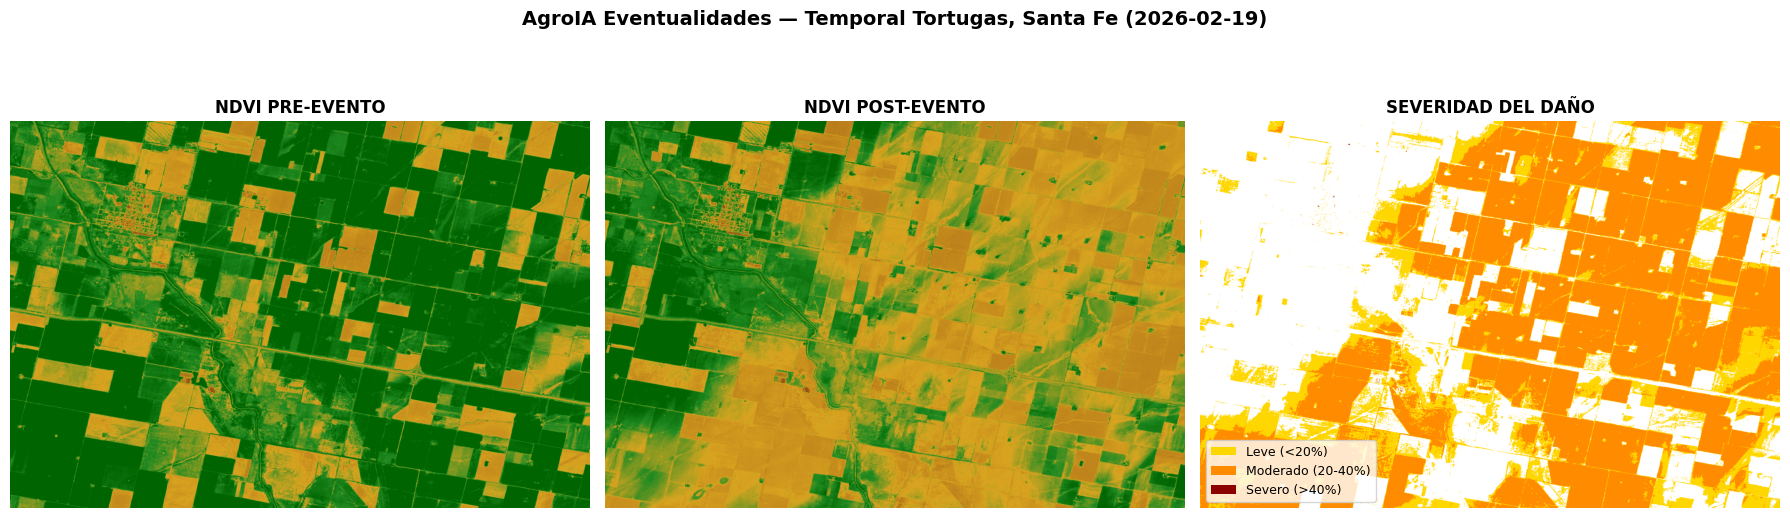

✅ Guardado: agroia_donut.png


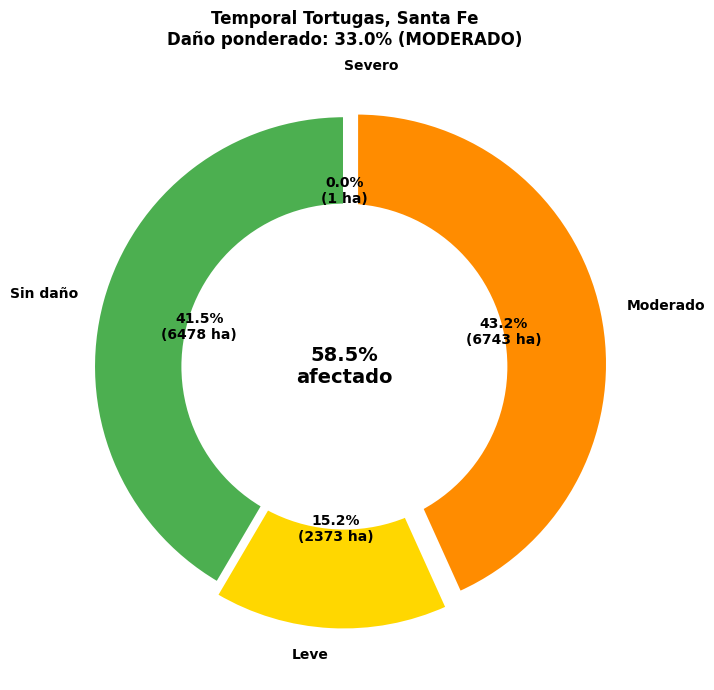

In [ ]:
# ============================================================
# CELDA 11 — Visualizaciones estaticas
# ============================================================
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

pal_ndvi = {'min':0,'max':0.8,'palette':['#8B4513','#DAA520','#228B22','#006400']}
pal_sev  = {'min':0,'max':3,  'palette':['#FFFFFF','#FFD700','#FF8C00','#8B0000']}
pal_dlt  = {'min':-0.5,'max':0.1,'palette':['#8B0000','#DC143C','#FF6347','#FFD700','#F0FFF0']}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'AgroIA Eventualidades — {CASO_NOMBRE} ({FECHA_EVENTO})', fontsize=14, fontweight='bold')

for ax, img, pal, title in zip(
    axes,
    [ndvi_pre, ndvi_post, severidad],
    [pal_ndvi, pal_ndvi, pal_sev],
    ['NDVI PRE-EVENTO', 'NDVI POST-EVENTO', 'SEVERIDAD DEL DAÑO']
):
    arr = geemap.ee_to_numpy(img.visualize(**pal), region=lote, scale=10)
    ax.imshow(arr); ax.set_title(title, fontweight='bold'); ax.axis('off')

# Leyenda en panel de severidad
axes[2].legend(handles=[
    Patch(facecolor='#FFD700', label='Leve (<20%)'),
    Patch(facecolor='#FF8C00', label='Moderado (20-40%)'),
    Patch(facecolor='#8B0000', label='Severo (>40%)'),
], loc='lower left', fontsize=9)

plt.tight_layout()
plt.savefig('agroia_comparativa.png', dpi=300, bbox_inches='tight')
print('✅ Guardado: agroia_comparativa.png')
plt.show()

# Donut
fig2, ax2 = plt.subplots(figsize=(8, 7))
sizes  = [area_total-area_afectada, area_leve, area_moderada, area_severa]
labels = ['Sin daño', 'Leve', 'Moderado', 'Severo']
colors = ['#4CAF50','#FFD700','#FF8C00','#8B0000']
ax2.pie(sizes, labels=labels, colors=colors,
        autopct=lambda p: f'{p:.1f}%\n({p*area_total/100:.0f} ha)',
        startangle=90, explode=(0,0.05,0.05,0.1),
        textprops={'fontsize':10,'fontweight':'bold'},
        wedgeprops={'edgecolor':'white','linewidth':2})
ax2.add_artist(plt.Circle((0,0),0.65,fc='white'))
ax2.text(0,0,f'{area_afectada/area_total*100:.1f}%\nafectado',
         ha='center',va='center',fontsize=14,fontweight='bold')
ax2.set_title(f'{CASO_NOMBRE}\nDaño ponderado: {dano_pond_val}% ({clasificacion})',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('agroia_donut.png', dpi=300, bbox_inches='tight')
print('✅ Guardado: agroia_donut.png')
plt.show()

In [ ]:
# ============================================================
# CELDA 12 — Reporte HTML ejecutivo
# ============================================================
nombre_html = f'reporte_agroia_{CULTIVO}_{FECHA_EVENTO}.html'

html = f"""
<!DOCTYPE html><html lang='es'><head><meta charset='UTF-8'>
<title>AgroIA Eventualidades — {CASO_NOMBRE}</title>
<style>
body{{font-family:'Segoe UI',Arial,sans-serif;margin:0;padding:20px;background:#f0f4f8;}}
.wrap{{max-width:960px;margin:auto;background:#fff;border-radius:16px;padding:32px;box-shadow:0 8px 30px rgba(0,0,0,.1);}}
h1{{color:#1a1a2e;border-left:6px solid #8B0000;padding-left:16px;font-size:1.4em;}}
h2{{color:#333;margin-top:28px;}}
.badge{{display:inline-block;padding:6px 18px;border-radius:20px;font-weight:bold;font-size:1.1em;}}
.leve{{background:#FFD700;color:#333;}}.moderado{{background:#FF8C00;color:#fff;}}.severo{{background:#8B0000;color:#fff;}}
.grid{{display:grid;grid-template-columns:repeat(auto-fit,minmax(150px,1fr));gap:14px;margin:20px 0;}}
.card{{background:#f7f9fc;border-radius:12px;padding:16px;text-align:center;}}
.num{{font-size:1.9em;font-weight:bold;color:#8B0000;}}
.formula{{background:#f0f4f8;border-left:4px solid #8B0000;padding:14px;border-radius:8px;font-family:monospace;margin:16px 0;}}
table{{width:100%;border-collapse:collapse;margin:12px 0;}}
th{{background:#8B0000;color:#fff;padding:10px;text-align:left;}}
td{{padding:9px;border-bottom:1px solid #eee;}}
.footer{{text-align:center;margin-top:28px;padding-top:18px;border-top:1px solid #ddd;color:#888;font-size:.85em;}}
</style></head><body><div class='wrap'>
<h1>Informe de Eventualidad Agricola — AgroIA</h1>
<p><b>Caso:</b> {CASO_NOMBRE} | <b>Evento:</b> {FECHA_EVENTO} ({TIPO_EVENTO}) | <b>Cultivo:</b> {CULTIVO.upper()}</p>
<p><b>Etapa fenologica:</b> {etapa_desc}</p>
<h2>Resultado del analisis</h2>
<p>Daño ponderado estimado: <span class='badge {clasificacion.lower()}'>{dano_pond_val}% — {clasificacion}</span></p>
<div class='grid'>
  <div class='card'><div>Area total</div><div class='num'>{area_total:.0f} ha</div></div>
  <div class='card'><div>Area afectada</div><div class='num'>{area_afectada:.0f} ha</div><div>({area_afectada/area_total*100:.1f}%)</div></div>
  <div class='card'><div>NDVI pre</div><div class='num'>{ndvi_pre_val}</div></div>
  <div class='card'><div>NDVI post</div><div class='num'>{ndvi_post_val}</div></div>
  <div class='card'><div>Delta relativo</div><div class='num'>{delta_rel_val}%</div></div>
  <div class='card'><div>Daño ponderado</div><div class='num'>{dano_pond_val}%</div></div>
</div>
<h2>Metodologia de ponderacion fenologica</h2>
<div class='formula'>
delta_rel      = (NDVI_pre - NDVI_post) / NDVI_pre x 100 = {delta_rel_val}%<br>
dano_ponderado = {delta_rel_val}% x {peso_fenologico} (peso fenologico) x {FACTOR_CONSERVADOR} (factor conservador)<br>
               = <b>{dano_pond_val}%</b>
</div>
<h2>Distribucion de daño por zona</h2>
<table>
<tr><th>Categoria</th><th>Area (ha)</th><th>% del lote</th></tr>
<tr><td>Leve (&lt;20%)</td><td>{area_leve:.1f}</td><td>{area_leve/area_total*100:.1f}%</td></tr>
<tr><td>Moderado (20-40%)</td><td>{area_moderada:.1f}</td><td>{area_moderada/area_total*100:.1f}%</td></tr>
<tr><td>Severo (&gt;40%)</td><td>{area_severa:.1f}</td><td>{area_severa/area_total*100:.1f}%</td></tr>
<tr><td><b>Total afectado</b></td><td><b>{area_afectada:.1f}</b></td><td><b>{area_afectada/area_total*100:.1f}%</b></td></tr>
</table>
<div class='footer'>
<p>AgroIA Eventualidades v2.0 | Sentinel-2 L2A (Copernicus, 10m) | Baseline 3 años</p>
<p>Generado el {datetime.now().strftime('%d/%m/%Y %H:%M')}</p>
</div></div></body></html>
"""

with open(nombre_html, 'w', encoding='utf-8') as f:
    f.write(html)
print(f'✅ Reporte HTML: {nombre_html}')

✅ Reporte HTML: reporte_agroia_maiz_2026-02-19.html


In [ ]:
# ============================================================
# CELDA 13 — Exportar a Google Drive
# ============================================================
carpeta = f'AgroIA_{CULTIVO}_{FECHA_EVENTO}'

exports = [
    (ndvi_pre,      'ndvi_pre',       {'min':0,'max':0.8,'palette':['#8B3A3A','#D4A017','#4CAF50','#1B5E20']}),
    (ndvi_post,     'ndvi_post',      {'min':0,'max':0.8,'palette':['#8B3A3A','#D4A017','#4CAF50','#1B5E20']}),
    (delta_adj,     'delta_ajustado', {'min':-0.5,'max':0.1,'palette':['#8B0000','#FF4500','#FFD700','#F0F0F0']}),
    (dano_pond_img, 'dano_ponderado', {'min':0,'max':100,'palette':['#F0F0F0','#FFD700','#FF8C00','#8B0000']}),
    (severidad,     'mapa_severidad', {'min':0,'max':3,'palette':['#FFFFFF','#FFD700','#FF8C00','#8B0000']}),
]

for img, name, vis in exports:
    task = ee.batch.Export.image.toDrive(
        image=img.visualize(**vis), description=name,
        folder=carpeta, fileNamePrefix=name,
        region=lote, scale=10, crs='EPSG:4326', maxPixels=1e9)
    task.start()
    print(f'  Exportando: {name} → Drive/{carpeta}')

print()
print('✅ PIPELINE COMPLETADO')
print(f'   Caso:           {CASO_NOMBRE}')
print(f'   Cultivo:        {CULTIVO.upper()} — {etapa_desc}')
print(f'   Daño ponderado: {dano_pond_val}% ({clasificacion})')
print(f'   Area afectada:  {area_afectada:.1f} ha de {area_total} ha')
print(f'   Reporte HTML:   {nombre_html}')

  Exportando: ndvi_pre → Drive/AgroIA_maiz_2026-02-19
  Exportando: ndvi_post → Drive/AgroIA_maiz_2026-02-19
  Exportando: delta_ajustado → Drive/AgroIA_maiz_2026-02-19
  Exportando: dano_ponderado → Drive/AgroIA_maiz_2026-02-19
  Exportando: mapa_severidad → Drive/AgroIA_maiz_2026-02-19

✅ PIPELINE COMPLETADO
   Caso:           Temporal Tortugas, Santa Fe
   Cultivo:        MAIZ — Llenado / madurez fisiologica (R4-R6)
   Daño ponderado: 33.0% (MODERADO)
   Area afectada:  9116.7 ha de 15594.8 ha
   Reporte HTML:   reporte_agroia_maiz_2026-02-19.html
